In [34]:
import re
import string
import nltk
import pandas as pd
from nltk.corpus import stopwords

# Pre-load data
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))
# Pre-create a translation table for speed
punct_table = str.maketrans("", "", string.punctuation)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    # Remove punctuation using the table
    text = text.translate(punct_table)
    # Filter stopwords and numeric tokens
    words = [w for w in text.split() if w not in stop_words and not w.isdigit()]
    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

import pandas as pd

X_train = pd.read_csv('X_train.csv', sep=';')
y_train = pd.read_csv('y_train.csv', sep=';')
X_test = pd.read_csv('X_train.csv', sep=';')
# Fill NaN values with empty string before vectorizing
X_train["description"] = X_train["description"].fillna("")

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5
)

X_text = tfidf.fit_transform(X_train["description"])

In [36]:
X_train["desc_length"] = X_train["description"].apply(lambda x: len(str(x)))
X_train["word_count"] = X_train["description"].apply(lambda x: len(str(x).split()))

In [37]:
def count_hashtags(text):
    return str(text).count("#")

X_train["hashtag_count"] = X_train["description"].apply(count_hashtags)

In [38]:
#!pip install emoji

In [39]:
import emoji

def count_emojis(text):
    return sum(1 for char in str(text) if char in emoji.EMOJI_DATA)

X_train["emoji_count"] = X_train["description"].apply(count_emojis)

In [40]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [41]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

X_train["sentiment"] = X_train["description"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

In [42]:
#!pip install vaderSentiment

Loading data...
Vectorizing text...
Training XGBoost with 5-Fold CV...
Fold 1 R2: 0.4254 | RMSE: 1.2350
Fold 2 R2: 0.4417 | RMSE: 1.2610
Fold 3 R2: 0.5156 | RMSE: 1.2086
Fold 4 R2: 0.3868 | RMSE: 1.3445
Fold 5 R2: 0.3958 | RMSE: 1.2763

Final Mean R2: 0.4331
Final Mean RMSE: 1.2651


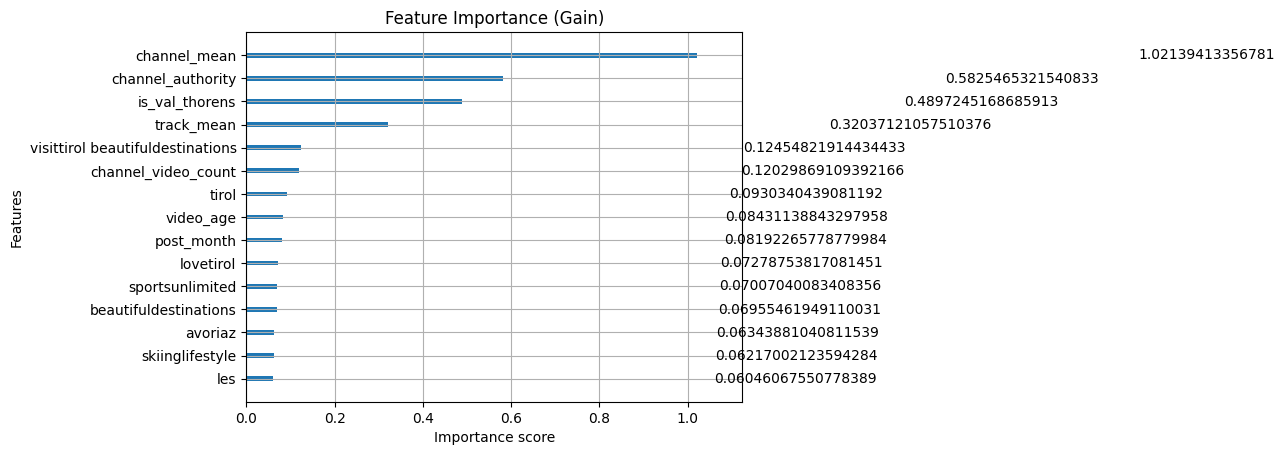

In [44]:
import pandas as pd
import numpy as np
import xgboost as xgb
import re
import ast
import string
import emoji
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize Sentiment
analyzer = SentimentIntensityAnalyzer()

def engineer_features(df):
    # 1. Cleaning & Basic Text Features
    df['description'] = df['description'].fillna('')
    df['desc_len'] = df['description'].apply(len)
    df['word_count'] = df['description'].apply(lambda x: len(str(x).split()))
    df['hashtag_count'] = df['description'].apply(lambda x: len(re.findall(r'#\w+', x)))
    df['mention_count'] = df['description'].apply(lambda x: len(re.findall(r'@\w+', x)))

    # Emoji Count (from your notebook)
    df['emoji_count'] = df['description'].apply(lambda x: sum(1 for char in str(x) if char in emoji.EMOJI_DATA))

    # 2. VADER Sentiment Analysis with Ski Slang
    ski_slang_map = {
        "sick": "amazing", "gnarly": "impressive", "insane": "incredible",
        "crushing": "performing well", "send it": "go for it", "fail": "funny mistake"
    }

    def get_sentiment(text):
        text = text.lower()
        for word, replacement in ski_slang_map.items():
            text = text.replace(word, replacement)
        return analyzer.polarity_scores(text)

    sent_scores = df['description'].apply(get_sentiment)
    sent_df = pd.DataFrame(list(sent_scores))
    df['sent_compound'] = sent_df['compound'].values

    # 3. Temporal Features (Target year 2026)
    df['video_age'] = 2026 - df['release_year'].fillna(df['release_year'].median())
    # Extract timestamp from ID if applicable
    df['post_date'] = df['id'].astype(int).apply(lambda x: pd.Timestamp((int(x) >> 32), unit='s'))
    df['post_month'] = df['post_date'].dt.month

    # 4. Metadata & Frequency
    df['artist_count'] = df['artists'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) and str(x).startswith('[') else 1)
    df['channel_video_count'] = df.groupby('channel')['id'].transform('count')

    # 5. Viral Pattern Features
    df['is_optimal_duration'] = df['video_duration'].between(6, 12).astype(int)
    df['is_minimalist'] = (df['desc_len'] <= 20).astype(int)
    df['is_val_thorens'] = (df['channel'].str.contains('Val Thorens', na=False)).astype(int)

    # Smoothed Channel Authority
    if 'popularity' in df.columns:
        alpha = 5
        global_mean = np.log1p(df['popularity']).mean()
        agg = df.groupby('channel')['popularity'].transform(lambda x: (np.log1p(x).sum() + alpha * global_mean) / (len(x) + alpha))
        df['channel_authority'] = agg
    else:
        df['channel_authority'] = 0

    return df

# --- MAIN EXECUTION ---
print("Loading data...")
X_df = pd.read_csv('X_train.csv', sep=';')
y_df = pd.read_csv('y_train.csv', sep=';')
data = X_df.merge(y_df, left_on='id', right_on='ID')

data = engineer_features(data)

# --- TF-IDF Processing ---
print("Vectorizing text...")
tfidf = TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(data['description'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

# Combine numeric features with TF-IDF features
numeric_features = [
    'desc_len', 'word_count', 'hashtag_count', 'emoji_count',
    'video_age', 'artist_count', 'video_duration',
    'channel_video_count', 'post_month', 'sent_compound',
    'is_optimal_duration', 'is_minimalist', 'is_val_thorens', 'channel_authority'
]
categorical_cols = ['channel', 'track']

X = pd.concat([data[numeric_features + categorical_cols], tfidf_df], axis=1)
y = np.log1p(data['popularity'])

print("Training XGBoost with 5-Fold CV...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Target Encoding for categorical variables
    for col in categorical_cols:
        mean_enc = y_train_fold.groupby(X_train_fold[col]).mean()
        X_train_fold[f'{col}_mean'] = X_train_fold[col].map(mean_enc).fillna(y_train_fold.mean())
        X_val_fold[f'{col}_mean'] = X_val_fold[col].map(mean_enc).fillna(y_train_fold.mean())

    X_train_fold = X_train_fold.drop(columns=categorical_cols)
    X_val_fold = X_val_fold.drop(columns=categorical_cols)

    model = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.7, tree_method='hist',
        early_stopping_rounds=50,
        random_state=42
    )

    model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

    preds = np.expm1(model.predict(X_val_fold))
    r2_scores.append(r2_score(np.expm1(y_val_fold), preds))
    rmse = np.sqrt(mean_squared_error(np.expm1(y_val_fold), preds))
    rmse_scores.append(rmse)
    print(f"Fold {fold+1} R2: {r2_scores[-1]:.4f} | RMSE: {rmse:.4f}")

print(f"\nFinal Mean R2: {np.mean(r2_scores):.4f}")
print(f"Final Mean RMSE: {np.mean(rmse_scores):.4f}")

# Plot Importance
xgb.plot_importance(model, importance_type='gain', max_num_features=15)
plt.title("Feature Importance (Gain)")
plt.show()

[I 2026-03-02 15:18:16,075] A new study created in memory with name: no-name-0ce451c3-1550-4227-b67a-9fd544fc5cb9


Running Optuna hyperparameter search (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-02 15:18:16,766] Trial 0 finished with value: 1.5219917386852764 and parameters: {'n_estimators': 534, 'learning_rate': 0.0150945582071978, 'max_depth': 6, 'subsample': 0.7736805947674956, 'colsample_bytree': 0.6762270292195534, 'min_child_weight': 4, 'gamma': 3.516193506075153, 'reg_alpha': 7.362124784767649e-07, 'reg_lambda': 0.00010309033990438183}. Best is trial 0 with value: 1.5219917386852764.
[I 2026-03-02 15:18:17,239] Trial 1 finished with value: 1.5284729117119618 and parameters: {'n_estimators': 321, 'learning_rate': 0.11161234714668697, 'max_depth': 8, 'subsample': 0.60651558227996, 'colsample_bytree': 0.7387290555033854, 'min_child_weight': 1, 'gamma': 3.5614343502005124, 'reg_alpha': 5.476654119209797e-07, 'reg_lambda': 0.005319604899751489}. Best is trial 0 with value: 1.5219917386852764.
[I 2026-03-02 15:18:18,118] Trial 2 finished with value: 1.461789133376777 and parameters: {'n_estimators': 1171, 'learning_rate': 0.019603559745451794, 'max_depth': 6, 'subs

/var/folders/j1/d32ct0l12lb578lj_3txypf00000gn/T/ipykernel_1964/3821294632.py:86: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


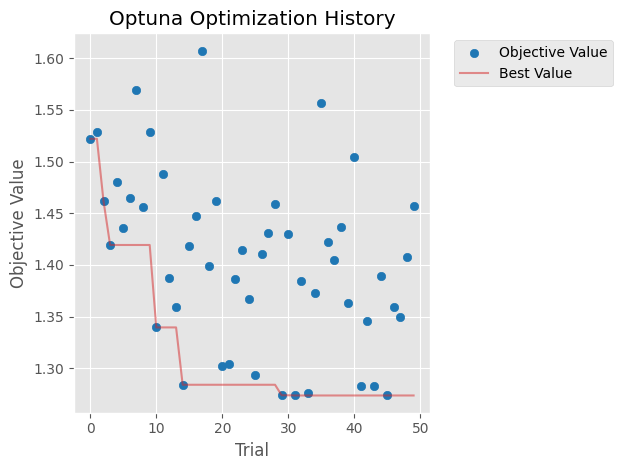

/var/folders/j1/d32ct0l12lb578lj_3txypf00000gn/T/ipykernel_1964/3821294632.py:90: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


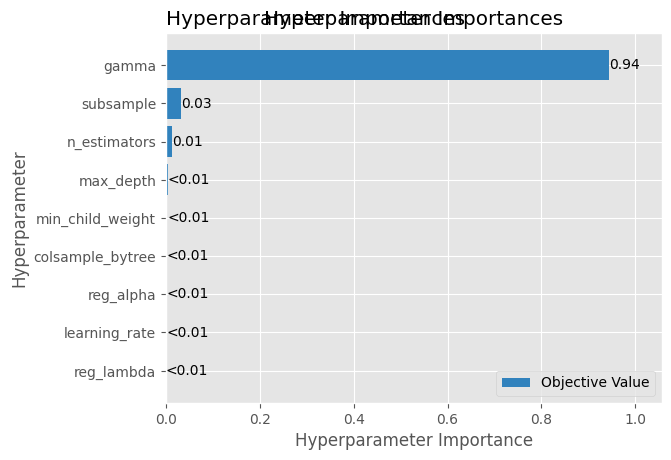

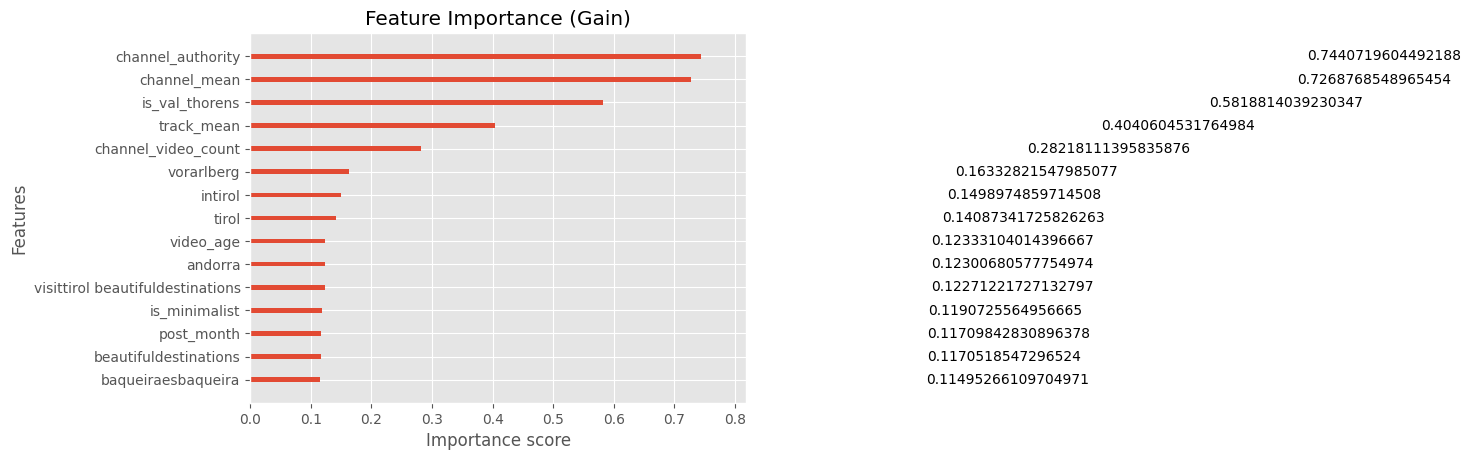

In [ ]:
import optuna

# --- OPTUNA OBJECTIVE ---
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'tree_method': 'hist',
        'random_state': 42
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        for col in categorical_cols:
            mean_enc = y_train_fold.groupby(X_train_fold[col]).mean()
            X_train_fold[f'{col}_mean'] = X_train_fold[col].map(mean_enc).fillna(y_train_fold.mean())
            X_val_fold[f'{col}_mean'] = X_val_fold[col].map(mean_enc).fillna(y_train_fold.mean())

        X_train_fold = X_train_fold.drop(columns=categorical_cols)
        X_val_fold = X_val_fold.drop(columns=categorical_cols)

        model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        preds = np.expm1(model.predict(X_val_fold))
        rmse = np.sqrt(mean_squared_error(np.expm1(y_val_fold), preds))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

# --- RUN OPTUNA ---
print("Running Optuna hyperparameter search (50 trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest RMSE: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

# --- TRAIN FINAL MODEL WITH BEST PARAMS ---
print("\nTraining final model with best parameters...")
best_params = study.best_params
best_params['tree_method'] = 'hist'
best_params['random_state'] = 42

kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    for col in categorical_cols:
        mean_enc = y_train_fold.groupby(X_train_fold[col]).mean()
        X_train_fold[f'{col}_mean'] = X_train_fold[col].map(mean_enc).fillna(y_train_fold.mean())
        X_val_fold[f'{col}_mean'] = X_val_fold[col].map(mean_enc).fillna(y_train_fold.mean())

    X_train_fold = X_train_fold.drop(columns=categorical_cols)
    X_val_fold = X_val_fold.drop(columns=categorical_cols)

    model = xgb.XGBRegressor(**best_params, early_stopping_rounds=50)
    model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

    preds = np.expm1(model.predict(X_val_fold))
    r2_scores.append(r2_score(np.expm1(y_val_fold), preds))
    rmse = np.sqrt(mean_squared_error(np.expm1(y_val_fold), preds))
    rmse_scores.append(rmse)
    print(f"Fold {fold+1} R2: {r2_scores[-1]:.4f} | RMSE: {rmse:.4f}")

print(f"\nFinal Mean R2: {np.mean(r2_scores):.4f}")
print(f"Final Mean RMSE: {np.mean(rmse_scores):.4f}")

# --- OPTUNA VISUALIZATION ---
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importances")
plt.show()

# --- FEATURE IMPORTANCE ---
xgb.plot_importance(model, importance_type='gain', max_num_features=15)
plt.title("Feature Importance (Gain)")
plt.show()

In [ ]:
# --- GENERATE SUBMISSION FROM TEXT MODEL ---
print("Loading and processing test data...")
X_test_raw = pd.read_csv('X_test.csv', sep=';')
test_ids = X_test_raw['id'].copy()

X_test_raw = engineer_features(X_test_raw)

# Apply channel authority from training data
channel_authority_map = data.groupby('channel')['channel_authority'].mean()
X_test_raw['channel_authority'] = X_test_raw['channel'].map(channel_authority_map).fillna(0)

# TF-IDF transform (using already fitted tfidf)
tfidf_test = pd.DataFrame(
    tfidf.transform(X_test_raw['description']).toarray(),
    columns=tfidf.get_feature_names_out()
)

X_test_final = pd.concat([
    X_test_raw[numeric_features + categorical_cols].reset_index(drop=True),
    tfidf_test
], axis=1)

# Target encoding using full training data encodings
channel_mean_enc = y.groupby(X['channel']).mean()
track_mean_enc = y.groupby(X['track']).mean()

X_test_final['channel_mean'] = X_test_final['channel'].map(channel_mean_enc).fillna(y.mean())
X_test_final['track_mean'] = X_test_final['track'].map(track_mean_enc).fillna(y.mean())
X_test_final = X_test_final.drop(columns=categorical_cols)

# Train final model on ALL training data with best params
print("Training final model on full training data...")
X_full = X.copy()
X_full['channel_mean'] = X_full['channel'].map(channel_mean_enc).fillna(y.mean())
X_full['track_mean'] = X_full['track'].map(track_mean_enc).fillna(y.mean())
X_full = X_full.drop(columns=categorical_cols)

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_full, y, verbose=False)

# Predict & save
predictions = np.expm1(final_model.predict(X_test_final))
predictions = np.clip(predictions, 0, None)  # no negative popularity

submission = pd.DataFrame({
    'ID': test_ids.values,
    'popularity': predictions
})

submission.to_csv('submission_text.csv', index=False, sep=',')
print(f"submission_text.csv saved — {len(submission)} rows")
print(submission.head())
print(submission['popularity'].describe())

Loading and processing test data...
Training final model on full training data...
submission_text.csv saved — 338 rows
                    ID  popularity
0  7568823330518748438    8.730117
1  7546523294489414934    8.830746
2  7504292781637127446    7.903373
3  7462655968522931478    8.504113
4  7442737337525669142    8.849721
count    338.000000
mean       7.629581
std        0.955240
min        5.117520
25%        6.983521
50%        7.478589
75%        8.139173
max       10.643340
Name: popularity, dtype: float64


## PART 2

In [27]:
import torch
from sentence_transformers import SentenceTransformer
import pandas as pd
import gc

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
model.max_seq_length = 64

# Pre-cleaning descriptions helps the transformer focus on meaning
descriptions = X_train["description"].fillna("").str.replace(r'http\S+', '', regex=True).tolist()

print("Generating embeddings...")
X_embeddings = model.encode(
    descriptions,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True # Normalizing helps downstream regression models
)

# Free up GPU memory immediately
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

df_embeddings = pd.DataFrame(X_embeddings, columns=[f'emb_{i}' for i in range(X_embeddings.shape[1])])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [28]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Improved Data Preparation
numeric_features = [
    'desc_len', 'word_count', 'hashtag_count', 'emoji_count',
    'video_age', 'artist_count', 'video_duration',
    'channel_video_count', 'post_month', 'sent_compound',
    'is_optimal_duration', 'is_minimalist', 'is_val_thorens', 'channel_authority'
]
categorical_cols = ['channel', 'track']

X_combined = pd.concat([
    data[numeric_features + categorical_cols].reset_index(drop=True),
    df_embeddings.reset_index(drop=True)
], axis=1)

# Log transformation is excellent for skewed 'popularity' metrics
y = np.log1p(data['popularity'])

# 2. Cross-Validation with Robust Encoding
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_combined)):
    X_train_f, X_val_f = X_combined.iloc[train_idx].copy(), X_combined.iloc[val_idx].copy()
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    # Target Encoding with Smoothing (Prevents Leakage/Overfitting)
    for col in categorical_cols:
        global_mean = y_train_f.mean()
        agg = y_train_f.groupby(X_train_f[col]).agg(['count', 'mean'])

        # Smoothing formula: (count * mean + weight * global_mean) / (count + weight)
        weight = 10
        smooth_mean = (agg['count'] * agg['mean'] + weight * global_mean) / (agg['count'] + weight)

        X_train_f[f'{col}_enc'] = X_train_f[col].map(smooth_mean).fillna(global_mean)
        X_val_f[f'{col}_enc'] = X_val_f[col].map(smooth_mean).fillna(global_mean)

    # Drop raw categories
    X_train_f.drop(columns=categorical_cols, inplace=True)
    X_val_f.drop(columns=categorical_cols, inplace=True)

    # Optimized XGBoost Parameters
    regressor = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.03, # Lower learning rate for better generalization
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.5, # Lower colsample helps with high-dim embeddings
        tree_method='hist',
        device=device,
        early_stopping_rounds=50,
        random_state=42
    )

    regressor.fit(X_train_f, y_train_f,
                  eval_set=[(X_val_f, y_val_f)],
                  verbose=False)

    # Evaluation
    preds_log = regressor.predict(X_val_f)
    preds = np.expm1(preds_log)
    true_vals = np.expm1(y_val_f)

    rmse = np.sqrt(mean_squared_error(true_vals, preds))
    mae = mean_absolute_error(true_vals, preds)
    r2 = r2_score(true_vals, preds)

    results.append({'rmse': rmse, 'r2': r2, 'mae': mae})
    print(f"Fold {fold+1} | RMSE: {rmse:.2f} | R2: {r2:.4f} | MAE: {mae:.2f}")

print(f"\nFinal R2: {np.mean([x['r2'] for x in results]):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [15:20:35] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold 1 | RMSE: 1.24 | R2: 0.4174 | MAE: 0.97
Fold 2 | RMSE: 1.25 | R2: 0.4501 | MAE: 0.94
Fold 3 | RMSE: 1.26 | R2: 0.4731 | MAE: 0.92
Fold 4 | RMSE: 1.34 | R2: 0.3909 | MAE: 1.03
Fold 5 | RMSE: 1.32 | R2: 0.3492 | MAE: 0.99

Final R2: 0.4162


In [45]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Dimensionality Reduction (The "Noise" Filter) ---
# 384 columns of embeddings can overwhelm 14 metadata columns.
# We compress embeddings to the top 50 components that explain most variance.
pca = PCA(n_components=50, random_state=42)
X_emb_reduced = pca.fit_transform(df_embeddings)
df_emb_pca = pd.DataFrame(X_emb_reduced, columns=[f'pca_{i}' for i in range(50)])



X_combined = pd.concat([
    data[numeric_features + categorical_cols].reset_index(drop=True),
    df_emb_pca.reset_index(drop=True)
], axis=1)

y = np.log1p(data['popularity'])

# --- 3. Optimized Training Loop ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_combined)):
    X_train_f, X_val_f = X_combined.iloc[train_idx].copy(), X_combined.iloc[val_idx].copy()
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    # Improved Smoothing for Target Encoding
    for col in categorical_cols:
        m = y_train_f.mean()
        # Add a tiny bit of Gaussian noise to the encoding to prevent overfitting
        mapping = y_train_f.groupby(X_train_f[col]).mean()
        X_train_f[f'{col}_enc'] = X_train_f[col].map(mapping).fillna(m) * np.random.normal(1, 0.01, len(X_train_f))
        X_val_f[f'{col}_enc'] = X_val_f[col].map(mapping).fillna(m)

    X_train_f.drop(columns=categorical_cols, inplace=True)
    X_val_f.drop(columns=categorical_cols, inplace=True)

    # --- GPU Optimized Model ---
    model = xgb.XGBRegressor(
        tree_method='hist',
        device="cuda",          # This fixes your warning
        n_estimators=3000,      # Higher estimators + lower learning rate
        learning_rate=0.02,     # Slow down learning for better precision
        max_depth=5,            # Shallow trees to prevent overfitting on embeddings
        subsample=0.8,
        colsample_bytree=0.6,
        reg_alpha=0.5,          # L1 Regularization
        reg_lambda=1.0,         # L2 Regularization
        early_stopping_rounds=100,
        random_state=42
    )

    model.fit(X_train_f, y_train_f,
              eval_set=[(X_val_f, y_val_f)],
              verbose=100)

    preds = np.expm1(model.predict(X_val_f))
    r2 = r2_score(np.expm1(y_val_f), preds)
    r2_scores.append(r2)
    print(f"Fold {fold+1} R2: {r2:.4f}")

print(f"\nImproved Mean R2: {np.mean(r2_scores):.4f}")

[0]	validation_0-rmse:0.18463
[100]	validation_0-rmse:0.14963
[200]	validation_0-rmse:0.14728
[300]	validation_0-rmse:0.14641
[400]	validation_0-rmse:0.14615
[500]	validation_0-rmse:0.14612
[600]	validation_0-rmse:0.14590
[700]	validation_0-rmse:0.14594
[719]	validation_0-rmse:0.14587
Fold 1 R2: 0.3942
[0]	validation_0-rmse:0.18632
[100]	validation_0-rmse:0.15025
[200]	validation_0-rmse:0.14558
[300]	validation_0-rmse:0.14419
[400]	validation_0-rmse:0.14402
[500]	validation_0-rmse:0.14376
[600]	validation_0-rmse:0.14361
[677]	validation_0-rmse:0.14377
Fold 2 R2: 0.4312
[0]	validation_0-rmse:0.18590
[100]	validation_0-rmse:0.14006
[200]	validation_0-rmse:0.13484
[300]	validation_0-rmse:0.13255
[400]	validation_0-rmse:0.13190
[500]	validation_0-rmse:0.13164
[600]	validation_0-rmse:0.13147
[700]	validation_0-rmse:0.13136
[800]	validation_0-rmse:0.13130
[900]	validation_0-rmse:0.13121
[1000]	validation_0-rmse:0.13124
[1029]	validation_0-rmse:0.13124
Fold 3 R2: 0.5175
[0]	validation_0-rmse:

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_emb_reduced = pca.fit_transform(df_embeddings)
df_emb_reduced = pd.DataFrame(X_emb_reduced, columns=[f'pca_{i}' for i in range(50)])

# Utilisez df_emb_reduced dans votre X_combined à la place de df_embeddings

In [47]:
import torch
import gc
import pandas as pd
import numpy as np
import xgboost as xgb
from sentence_transformers import SentenceTransformer

# --- 1. LOAD TEST DATA ---
print("Loading and processing test data...")
X_test_raw = pd.read_csv('X_test.csv', sep=';')
test_ids = X_test_raw['id'].copy()

# Apply your custom engineering function
X_test_raw = engineer_features(X_test_raw)

# Apply channel authority (mapping from training data 'data')
channel_authority_map = data.groupby('channel')['channel_authority'].mean()
X_test_raw['channel_authority'] = X_test_raw['channel'].map(channel_authority_map).fillna(data['channel_authority'].mean())

# --- 2. GENERATE TEST EMBEDDINGS ---
print("Generating test embeddings...")
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
model.max_seq_length = 64

# Clean descriptions for consistency
test_descriptions = X_test_raw["description"].fillna("").str.replace(r'http\S+', '', regex=True).tolist()

X_test_emb = model.encode(
    test_descriptions,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

# Free GPU memory
del model
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

# Apply the ALREADY FITTED PCA from the training step
X_test_pca = pca.transform(X_test_emb)
df_test_pca = pd.DataFrame(X_test_pca, columns=[f'pca_{i}' for i in range(X_test_pca.shape[1])])

# --- 3. PREPARE FINAL FEATURES ---
# Combine metadata and PCA components
X_test_final = pd.concat([
    X_test_raw[numeric_features + categorical_cols].reset_index(drop=True),
    df_test_pca
], axis=1)

# Target Encoding using global means from training
global_mean = y.mean()
channel_enc = y.groupby(data['channel']).mean()
track_enc = y.groupby(data['track']).mean()

X_test_final['channel_enc'] = X_test_final['channel'].map(channel_enc).fillna(global_mean)
X_test_final['track_enc'] = X_test_final['track'].map(track_enc).fillna(global_mean)

# Drop raw categories to match training format
X_test_final = X_test_final.drop(columns=categorical_cols)

# --- 4. TRAIN FINAL MODEL ON FULL DATA ---
print("Training final model on 100% of training data...")

# Prepare X_full (Training set with same PCA and Encodings)
X_full = pd.concat([
    data[numeric_features].reset_index(drop=True),
    data[['channel', 'track']].reset_index(drop=True),
    df_emb_pca # This is the PCA version of training embeddings you created earlier
], axis=1)

X_full['channel_enc'] = X_full['channel'].map(channel_enc).fillna(global_mean)
X_full['track_enc'] = X_full['track'].map(track_enc).fillna(global_mean)
X_full = X_full.drop(columns=['channel', 'track'])

# Use the improved params we discussed (tuned for GPU)
final_params = {
    'tree_method': 'hist',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'n_estimators': 1200, # Increased slightly since we are using more data
    'learning_rate': 0.02,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'random_state': 42
}

final_model = xgb.XGBRegressor(**final_params)
final_model.fit(X_full, y)

# --- 5. PREDICT & SAVE ---
print("Generating final predictions...")
# Ensure column order matches exactly
X_test_final = X_test_final[X_full.columns]

predictions = np.expm1(final_model.predict(X_test_final))
predictions = np.clip(predictions, 0, None)

submission = pd.DataFrame({
    'ID': test_ids.values,
    'popularity': predictions
})

submission.to_csv('submission_transformer.csv', index=False, sep=',')
print(f"Success! Saved {len(submission)} rows.")
print(submission['popularity'].describe())

Loading and processing test data...
Generating test embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Training final model on 100% of training data...
Generating final predictions...
Success! Saved 338 rows.
count    338.000000
mean       7.668736
std        0.992140
min        5.393269
25%        6.943673
50%        7.574071
75%        8.093781
max       10.702619
Name: popularity, dtype: float64


## PART 3 AJOUT SON

In [48]:
#pip install tensorflow tensorflow-hub librosa soundfile

In [ ]:
import subprocess
import os

def extract_audio_from_video(video_path, output_path="temp_audio.wav"):
    """
    Extrait l'audio d'un fichier MP4 et le sauvegarde en WAV.
    Utilise ffmpeg (doit être installé sur le système).
    """
    command = [
        "ffmpeg",
        "-i", str(video_path),   # fichier d'entrée
        "-ar", "16000",          # resample à 16kHz (requis par YAMNet)
        "-ac", "1",              # mono (1 canal)
        "-f", "wav",             # format WAV
        output_path,
        "-y",                    # écraser si le fichier existe déjà
        "-loglevel", "quiet"     # pas de logs ffmpeg
    ]
    subprocess.run(command)
    return output_path

# Test sur une vidéo
audio_path = extract_audio_from_video("/home/jmaubian/SDD/Hackathon/videos_mp4/downloads/USER_alpedhuez/VIDEO_6814175723704683782.mp4")
print(f"Audio extrait : {audio_path}")

In [60]:
import torch
import gc
import re
import ast
import pandas as pd
import numpy as np
import xgboost as xgb
import emoji
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

# --- 1. DEFINE FEATURE ENGINEERING ---
def engineer_features(df, is_train=True, training_data=None):
    df = df.copy()
    df['description'] = df['description'].fillna('')

    # Text Features
    df['desc_len'] = df['description'].apply(len)
    df['word_count'] = df['description'].apply(lambda x: len(str(x).split()))
    df['hashtag_count'] = df['description'].apply(lambda x: len(re.findall(r'#\w+', x)))
    df['emoji_count'] = df['description'].apply(lambda x: sum(1 for char in str(x) if char in emoji.EMOJI_DATA))

    # Sentiment
    df['sent_compound'] = df['description'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

    # Temporal
    df['video_age'] = 2026 - df['release_year'].fillna(df['release_year'].median())
    df['post_date'] = df['id'].astype(int).apply(lambda x: pd.Timestamp((int(x) >> 32), unit='s'))
    df['post_month'] = df['post_date'].dt.month

    # Metadata
    df['artist_count'] = df['artists'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) and str(x).startswith('[') else 1)

    # Viral Patterns
    df['is_optimal_duration'] = df['video_duration'].between(6, 12).astype(int)
    df['is_minimalist'] = (df['desc_len'] <= 20).astype(int)
    df['is_val_thorens'] = (df['channel'].str.contains('Val Thorens', na=False)).astype(int)

    # Channel Authority & Global Stats (Calculated from Training Data)
    if is_train:
        df['channel_video_count'] = df.groupby('channel')['id'].transform('count')
        # Smoothed Channel Authority
        alpha = 5
        global_mean_pop = np.log1p(df['popularity']).mean()
        df['channel_authority'] = df.groupby('channel')['popularity'].transform(
            lambda x: (np.log1p(x).sum() + alpha * global_mean_pop) / (len(x) + alpha)
        )
    else:
        # Map values from training data to avoid leakage
        channel_video_map = training_data.groupby('channel')['id'].count()
        channel_auth_map = training_data.groupby('channel')['channel_authority'].mean()
        df['channel_video_count'] = df['channel'].map(channel_video_map).fillna(0)
        df['channel_authority'] = df['channel'].map(channel_auth_map).fillna(training_data['channel_authority'].mean())

    # Interaction Feature
    df['engagement_rate_potential'] = df['channel_authority'] * df['video_duration']

    return df

# --- 2. DATA LOADING & MERGING ---
print("Loading data...")
X_train_raw = pd.read_csv('X_train.csv', sep=';')
y_train_raw = pd.read_csv('y_train.csv', sep=';')
train_data = X_train_raw.merge(y_train_raw, left_on='id', right_on='ID')

X_test_raw = pd.read_csv('X_test.csv', sep=';')
audio_data = pd.read_csv('audio_features_ready.csv')

# Define feature lists
audio_cols = ['tempo', 'energy_mean', 'mfcc_1', 'mfcc_2', 'yamnet_music_score', 'yamnet_speech_score', 'is_music', 'is_speech']
metadata_numeric = [
    'desc_len', 'word_count', 'hashtag_count', 'emoji_count', 'video_age', 'artist_count',
    'video_duration', 'channel_video_count', 'post_month', 'sent_compound',
    'is_optimal_duration', 'is_minimalist', 'is_val_thorens', 'channel_authority', 'engagement_rate_potential'
]
categorical_cols = ['channel', 'track']

numeric_features = metadata_numeric + audio_cols


# 1. "High Energy Trend" Interaction
# Short videos (< 15s) with high energy and music are usually viral dance/trend videos.
df['is_high_energy_trend'] = ((df['video_duration'] < 15) &
                              (df['is_music'] == 1) &
                              (df['energy_mean'] > df['energy_mean'].median())).astype(int)

# 2. Vibe Index
# Fast tempo + High energy usually correlates with higher engagement on TikTok
df['vibe_index'] = df['tempo'] * df['energy_mean']

# 3. Speech Density / Pacing
# If it's a speech video, how fast are they talking? (Approximated by tempo/mfcc variance)
df['speech_pace'] = df['is_speech'] * df['tempo']

# Apply Engineering and Merging
print("Engineering features...")
train_data = engineer_features(train_data, is_train=True)
X_test_processed = engineer_features(X_test_raw, is_train=False, training_data=train_data)

# Merge Audio
train_data = train_data.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)
X_test_processed = X_test_processed.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)

# --- 3. GENERATE EMBEDDINGS & PCA ---
print("Generating Embeddings...")
device = "cuda" if torch.cuda.is_available() else "cpu"
st_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
st_model.max_seq_length = 64

train_emb = st_model.encode(train_data['description'].tolist(), batch_size=64, show_progress_bar=True)
test_emb = st_model.encode(X_test_processed['description'].tolist(), batch_size=64, show_progress_bar=True)

# PCA Reduction to 50 dims
pca = PCA(n_components=50, random_state=42)
train_pca = pca.fit_transform(train_emb)
test_pca = pca.transform(test_emb)

df_train_pca = pd.DataFrame(train_pca, columns=[f'pca_{i}' for i in range(50)])
df_test_pca = pd.DataFrame(test_pca, columns=[f'pca_{i}' for i in range(50)])

# --- 4. PREPARE FINAL X AND Y ---
y = np.log1p(train_data['popularity'])
global_mean_y = y.mean()

# Target Encoding
X_full = pd.concat([train_data[numeric_features + categorical_cols], df_train_pca], axis=1)
X_test_final = pd.concat([X_test_processed[numeric_features + categorical_cols], df_test_pca], axis=1)

for col in categorical_cols:
    mapping = y.groupby(train_data[col]).mean()
    X_full[f'{col}_enc'] = X_full[col].map(mapping).fillna(global_mean_y)
    X_test_final[f'{col}_enc'] = X_test_final[col].map(mapping).fillna(global_mean_y)

X_full = X_full.drop(columns=categorical_cols)
X_test_final = X_test_final.drop(columns=categorical_cols)
X_test_final = X_test_final[X_full.columns] # Ensure alignment

# --- 5. FINAL MODEL & SUBMISSION ---
print("Training final model...")
final_model = xgb.XGBRegressor(
    tree_method='hist', device=device,
    n_estimators=1500, learning_rate=0.015, max_depth=6,
    subsample=0.8, colsample_bytree=0.5, random_state=42
)

final_model.fit(X_full, y)
preds = np.expm1(final_model.predict(X_test_final))

submission = pd.DataFrame({'ID': X_test_raw['id'], 'popularity': np.clip(preds, 0, None)})
submission.to_csv('submission_final.csv', index=False)
print("Done! saved to submission_final.csv")

Loading data...


NameError: name 'df' is not defined

In [57]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
import numpy as np

# 1. Base Setup (Assume train_data contains raw data + audio, NO target-engineered features yet)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_list, r2_list = [], []

print("Starting LEAK-FREE Cross-Validation...")

# Note: train_emb is your Sentence Transformer numpy array from earlier
# train_data should be raw features + audio (no channel_authority, no target encoding)

for fold, (train_idx, val_idx) in enumerate(kf.split(train_data)):
    # --- 1. STRICT SPLIT FIRST ---
    df_tr = train_data.iloc[train_idx].copy()
    df_va = train_data.iloc[val_idx].copy()

    y_tr = np.log1p(df_tr['popularity'])
    y_va = np.log1p(df_va['popularity'])

    # --- 2. NO-LEAK TARGET ENCODING & AUTHORITY ---
    # Calculate global mean strictly from the training fold
    global_mean_y = y_tr.mean()

    # Target Encoding
    for col in categorical_cols: # ['channel', 'track']
        mapping = y_tr.groupby(df_tr[col]).mean()
        df_tr[f'{col}_enc'] = df_tr[col].map(mapping).fillna(global_mean_y)
        df_va[f'{col}_enc'] = df_va[col].map(mapping).fillna(global_mean_y)

    # Channel Authority & Engagement Rate Potential
    alpha = 5
    auth_mapping = df_tr.groupby('channel')['popularity'].apply(
        lambda x: (np.log1p(x).sum() + alpha * global_mean_y) / (len(x) + alpha)
    )
    df_tr['channel_authority'] = df_tr['channel'].map(auth_mapping).fillna(global_mean_y)
    df_va['channel_authority'] = df_va['channel'].map(auth_mapping).fillna(global_mean_y)

    df_tr['engagement_rate_potential'] = df_tr['channel_authority'] * df_tr['video_duration']
    df_va['engagement_rate_potential'] = df_va['channel_authority'] * df_va['video_duration']

    # --- 3. NO-LEAK PCA ---
    emb_tr = train_emb[train_idx]
    emb_va = train_emb[val_idx]

    fold_pca = PCA(n_components=50, random_state=42)
    pca_tr = pd.DataFrame(fold_pca.fit_transform(emb_tr), columns=[f'pca_{i}' for i in range(50)], index=df_tr.index)
    pca_va = pd.DataFrame(fold_pca.transform(emb_va), columns=[f'pca_{i}' for i in range(50)], index=df_va.index)

    # --- 4. COMBINE FINAL FEATURES ---
    # List of numeric features MINUS the raw categorical ones
    numeric_features = [
        'desc_len', 'word_count', 'hashtag_count', 'emoji_count', 'video_age', 'artist_count',
        'video_duration', 'channel_video_count', 'post_month', 'sent_compound',
        'is_optimal_duration', 'is_minimalist', 'is_val_thorens', 'channel_authority', 'engagement_rate_potential'
    ] + audio_cols # (ensure audio_cols is defined from earlier)

    X_tr = pd.concat([df_tr[numeric_features], df_tr[[c + '_enc' for c in categorical_cols]], pca_tr], axis=1)
    X_va = pd.concat([df_va[numeric_features], df_va[[c + '_enc' for c in categorical_cols]], pca_va], axis=1)

    # --- 5. TRAIN & EVALUATE ---
    fold_model = xgb.XGBRegressor(
        tree_method='hist',
        device="cuda" if torch.cuda.is_available() else "cpu",
        n_estimators=1500, learning_rate=0.015, max_depth=6,
        subsample=0.8, colsample_bytree=0.5, random_state=42, early_stopping_rounds=50
    )

    fold_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    # Revert log transform for real-world metrics
    true_vals = np.expm1(y_va)
    pred_vals = np.expm1(fold_model.predict(X_va))

    fold_rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    fold_r2 = r2_score(true_vals, pred_vals)

    rmse_list.append(fold_rmse)
    r2_list.append(fold_r2)
    print(f"Fold {fold+1} | LEAK-FREE RMSE: {fold_rmse:.4f} | LEAK-FREE R2: {fold_r2:.4f}")

print("\n=== TRUE GENERALIZATION PERFORMANCE ===")
print(f"Mean RMSE: {np.mean(rmse_list):.4f}")
print(f"Mean R2 Score: {np.mean(r2_list):.4f}")

Starting LEAK-FREE Cross-Validation...
Fold 1 | LEAK-FREE RMSE: 1.2462 | LEAK-FREE R2: 0.4149
Fold 2 | LEAK-FREE RMSE: 1.2260 | LEAK-FREE R2: 0.4723
Fold 3 | LEAK-FREE RMSE: 1.2179 | LEAK-FREE R2: 0.5082
Fold 4 | LEAK-FREE RMSE: 1.2742 | LEAK-FREE R2: 0.4491
Fold 5 | LEAK-FREE RMSE: 1.2716 | LEAK-FREE R2: 0.4002

=== TRUE GENERALIZATION PERFORMANCE ===
Mean RMSE: 1.2472
Mean R2 Score: 0.4489


In [63]:
import torch
import gc
import re
import ast
import pandas as pd
import numpy as np
import xgboost as xgb
import emoji
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# Initialize Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

# --- 1. DEFINE ROBUST FEATURE ENGINEERING ---
def engineer_base_features(df):
    """Features that do not depend on the target variable (safe to run on full data)"""
    df = df.copy()

    # Force 'description' to string to prevent TypeError: int has no len()
    df['description'] = df['description'].astype(str).replace('nan', '')

    # Text Features
    df['desc_len'] = df['description'].apply(lambda x: len(x))
    df['word_count'] = df['description'].apply(lambda x: len(x.split()))
    df['hashtag_count'] = df['description'].apply(lambda x: len(re.findall(r'#\w+', x)))
    df['emoji_count'] = df['description'].apply(lambda x: sum(1 for char in x if char in emoji.EMOJI_DATA))

    # Sentiment (VADER)
    df['sent_compound'] = df['description'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

    # Temporal
    # Handle IDs that might be non-numeric gracefully
    def get_timestamp(id_val):
        try:
            return pd.Timestamp((int(id_val) >> 32), unit='s')
        except:
            return pd.Timestamp('2024-01-01')

    df['post_date'] = df['id'].apply(get_timestamp)
    df['post_month'] = df['post_date'].dt.month
    df['video_age'] = 2026 - df['release_year'].fillna(df['release_year'].median())

    # Metadata
    def safe_artist_len(x):
        if pd.isna(x) or not str(x).startswith('['): return 1
        try: return len(ast.literal_eval(str(x)))
        except: return 1

    df['artist_count'] = df['artists'].apply(safe_artist_len)

    # Viral Patterns
    df['is_optimal_duration'] = df['video_duration'].between(6, 12).astype(int)
    df['is_minimalist'] = (df['desc_len'] <= 20).astype(int)
    df['is_val_thorens'] = (df['channel'].astype(str).str.contains('Val Thorens', na=False)).astype(int)

    return df

# --- 2. DATA LOADING & PRE-PROCESSING ---
print("Loading data...")
X_train_raw = pd.read_csv('X_train.csv', sep=';')
y_train_raw = pd.read_csv('y_train.csv', sep=';')
train_data = X_train_raw.merge(y_train_raw, left_on='id', right_on='ID').drop_duplicates(subset='id')

X_test_raw = pd.read_csv('X_test.csv', sep=';')
audio_data = pd.read_csv('audio_features_ready.csv').drop_duplicates(subset='id')

# Define column groups
audio_cols = ['tempo', 'energy_mean', 'mfcc_1', 'mfcc_2', 'yamnet_music_score', 'yamnet_speech_score', 'is_music', 'is_speech']
meta_numeric = [
    'desc_len', 'word_count', 'hashtag_count', 'emoji_count', 'video_age', 'artist_count',
    'video_duration', 'post_month', 'sent_compound', 'is_optimal_duration', 'is_minimalist', 'is_val_thorens'
]
categorical_cols = ['channel', 'track']

# Apply base engineering
print("Applying base engineering...")
train_data = engineer_base_features(train_data)
X_test_processed = engineer_base_features(X_test_raw)

# Merge Audio
train_data = train_data.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)
X_test_processed = X_test_processed.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)

# --- 3. EMBEDDINGS (Run once for performance) ---
print("Generating Embeddings...")
device = "cuda" if torch.cuda.is_available() else "cpu"
st_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

train_emb = st_model.encode(train_data['description'].tolist(), batch_size=64, show_progress_bar=True)
test_emb = st_model.encode(X_test_processed['description'].tolist(), batch_size=64, show_progress_bar=True)

# --- 4. LEAK-FREE CROSS VALIDATION ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []
final_test_preds = []

print("\nStarting Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(kf.split(train_data)):
    # Split
    df_tr, df_va = train_data.iloc[train_idx].copy(), train_data.iloc[val_idx].copy()
    y_tr, y_va = np.log1p(df_tr['popularity']), np.log1p(df_va['popularity'])

    # Target Encoding (Calculated only on df_tr)
    global_mean_y = y_tr.mean()
    for col in categorical_cols:
        mapping = y_tr.groupby(df_tr[col]).mean()
        df_tr[f'{col}_enc'] = df_tr[col].map(mapping).fillna(global_mean_y)
        df_va[f'{col}_enc'] = df_va[col].map(mapping).fillna(global_mean_y)

    # Channel Authority
    alpha = 5
    auth_mapping = df_tr.groupby('channel')['popularity'].apply(
        lambda x: (np.log1p(x).sum() + alpha * global_mean_y) / (len(x) + alpha)
    )
    df_tr['channel_authority'] = df_tr['channel'].map(auth_mapping).fillna(global_mean_y)
    df_va['channel_authority'] = df_va['channel'].map(auth_mapping).fillna(global_mean_y)

    # Interactions
    df_tr['engagement_rate_potential'] = df_tr['channel_authority'] * df_tr['video_duration']
    df_va['engagement_rate_potential'] = df_va['channel_authority'] * df_va['video_duration']

    # PCA (Fit on train fold only)
    pca = PCA(n_components=50, random_state=42)
    pca_tr = pca.fit_transform(train_emb[train_idx])
    pca_va = pca.transform(train_emb[val_idx])

    # Final X construction
    dynamic_cols = ['channel_enc', 'track_enc', 'channel_authority', 'engagement_rate_potential']
    all_features = meta_numeric + audio_cols + dynamic_cols

    X_tr = np.hstack([df_tr[all_features].values, pca_tr])
    X_va = np.hstack([df_va[all_features].values, pca_va])

    # Model
    model = xgb.XGBRegressor(
        tree_method='hist', device=device,
        n_estimators=1000, learning_rate=0.02, max_depth=6,
        subsample=0.8, colsample_bytree=0.6, random_state=42,early_stopping_rounds=50
    )

    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    # Evaluate
    preds = np.expm1(model.predict(X_va))
    fold_rmse = np.sqrt(mean_squared_error(np.expm1(y_va), preds))
    rmse_scores.append(fold_rmse)
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

print(f"\nMean CV RMSE: {np.mean(rmse_scores):.4f}")

# --- 5. FINAL INFERENCE ON TEST SET ---
print("\nTraining final model on full dataset...")
# Apply dynamic features to the full train/test set
y_full = np.log1p(train_data['popularity'])
global_mean_full = y_full.mean()

for col in categorical_cols:
    mapping = y_full.groupby(train_data[col]).mean()
    train_data[f'{col}_enc'] = train_data[col].map(mapping).fillna(global_mean_full)
    X_test_processed[f'{col}_enc'] = X_test_processed[col].map(mapping).fillna(global_mean_full)

auth_full = train_data.groupby('channel')['popularity'].apply(
    lambda x: (np.log1p(x).sum() + 5 * global_mean_full) / (len(x) + 5)
)
train_data['channel_authority'] = train_data['channel'].map(auth_full).fillna(global_mean_full)
X_test_processed['channel_authority'] = X_test_processed['channel'].map(auth_full).fillna(global_mean_full)

train_data['engagement_rate_potential'] = train_data['channel_authority'] * train_data['video_duration']
X_test_processed['engagement_rate_potential'] = X_test_processed['channel_authority'] * X_test_processed['video_duration']

pca_final = PCA(n_components=50, random_state=42)
pca_tr_final = pca_final.fit_transform(train_emb)
pca_te_final = pca_final.transform(test_emb)

X_train_final = np.hstack([train_data[all_features].values, pca_tr_final])
X_test_final = np.hstack([X_test_processed[all_features].values, pca_te_final])

final_model = xgb.XGBRegressor(tree_method='hist', device=device, n_estimators=1200, learning_rate=0.015, max_depth=6)
final_model.fit(X_train_final, y_full)

preds_final = np.expm1(final_model.predict(X_test_final))

# Save submission
submission = pd.DataFrame({'ID': X_test_raw['id'], 'popularity': np.clip(preds_final, 0, None)})
submission.to_csv('submission_final.csv', index=False)
print("Done! Results saved to submission_final.csv")

Loading data...
Applying base engineering...
Generating Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Starting Cross-Validation...
Fold 1 RMSE: 1.2507
Fold 2 RMSE: 1.2465
Fold 3 RMSE: 1.2452
Fold 4 RMSE: 1.2950
Fold 5 RMSE: 1.2793

Mean CV RMSE: 1.2633

Training final model on full dataset...
Done! Results saved to submission_final.csv


In [68]:
import torch
import gc
import re
import ast
import pandas as pd
import numpy as np
import xgboost as xgb
import emoji
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# Initialize Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

# --- 1. DEFINE ROBUST FEATURE ENGINEERING ---
def engineer_base_features(df):
    df = df.copy()

    # Defensive casting to prevent TypeError
    df['description'] = df['description'].astype(str).replace('nan', '')

    # Text Features
    df['desc_len'] = df['description'].apply(lambda x: len(x))
    df['word_count'] = df['description'].apply(lambda x: len(x.split()))
    df['hashtag_count'] = df['description'].apply(lambda x: len(re.findall(r'#\w+', x)))
    df['emoji_count'] = df['description'].apply(lambda x: sum(1 for char in x if char in emoji.EMOJI_DATA))
    df['sent_compound'] = df['description'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

    # Temporal
    def get_timestamp(id_val):
        try: return pd.Timestamp((int(id_val) >> 32), unit='s')
        except: return pd.Timestamp('2024-01-01')

    df['post_date'] = df['id'].apply(get_timestamp)
    df['post_month'] = df['post_date'].dt.month
    df['video_age'] = 2026 - df['release_year'].fillna(df['release_year'].median())

    # Metadata
    def safe_artist_len(x):
        if pd.isna(x) or not str(x).startswith('['): return 1
        try: return len(ast.literal_eval(str(x)))
        except: return 1
    df['artist_count'] = df['artists'].apply(safe_artist_len)

    # Viral Patterns (Metadata)
    df['is_optimal_duration'] = df['video_duration'].between(6, 12).astype(int)
    df['is_minimalist'] = (df['desc_len'] <= 20).astype(int)
    df['is_val_thorens'] = (df['channel'].astype(str).str.contains('Val Thorens', na=False)).astype(int)

    # --- NEW: Viral Audio Interactions ---
    # 1. "High Energy Trend"
    energy_median = df['energy_mean'].median() if 'energy_mean' in df.columns else 0.5
    df['is_high_energy_trend'] = ((df['video_duration'] < 15) &
                                  (df.get('is_music', 0) == 1) &
                                  (df.get('energy_mean', 0) > energy_median)).astype(int)

    # 2. Vibe Index
    df['vibe_index'] = df.get('tempo', 0) * df.get('energy_mean', 0)

    # 3. Speech Density / Pacing
    df['speech_pace'] = df.get('is_speech', 0) * df.get('tempo', 0)

    return df

# --- 2. DATA LOADING ---
print("Loading and Merging data...")
X_train_raw = pd.read_csv('X_train.csv', sep=';')
y_train_raw = pd.read_csv('y_train.csv', sep=';')
train_data = X_train_raw.merge(y_train_raw, left_on='id', right_on='ID').drop_duplicates(subset='id')

X_test_raw = pd.read_csv('X_test.csv', sep=';')
audio_data = pd.read_csv('audio_features_ready.csv').drop_duplicates(subset='id')

# Merge Audio BEFORE feature engineering so interaction terms have the data they need
audio_cols = ['tempo', 'energy_mean', 'mfcc_1', 'mfcc_2', 'yamnet_music_score', 'yamnet_speech_score', 'is_music', 'is_speech']
train_data = train_data.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)
X_test_processed = X_test_raw.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)

# Apply engineering
train_data = engineer_base_features(train_data)
X_test_processed = engineer_base_features(X_test_processed)

# Define feature lists
meta_numeric = [
    'desc_len', 'word_count', 'hashtag_count', 'emoji_count', 'video_age', 'artist_count',
    'video_duration', 'post_month', 'sent_compound', 'is_optimal_duration', 'is_minimalist',
    'is_val_thorens', 'is_high_energy_trend', 'vibe_index', 'speech_pace'
]
categorical_cols = ['channel', 'track']
all_base_features = meta_numeric + audio_cols

# --- 3. EMBEDDINGS ---
print("Generating Embeddings...")
device = "cuda" if torch.cuda.is_available() else "cpu"
st_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
train_emb = st_model.encode(train_data['description'].tolist(), batch_size=64, show_progress_bar=True)
test_emb = st_model.encode(X_test_processed['description'].tolist(), batch_size=64, show_progress_bar=True)

# --- 4. LEAK-FREE CROSS VALIDATION ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_data)):
    df_tr, df_va = train_data.iloc[train_idx].copy(), train_data.iloc[val_idx].copy()
    y_tr, y_va = np.log1p(df_tr['popularity']), np.log1p(df_va['popularity'])

    # Fold-based Target Encoding
    global_mean_y = y_tr.mean()
    for col in categorical_cols:
        mapping = y_tr.groupby(df_tr[col]).mean()
        df_tr[f'{col}_enc'] = df_tr[col].map(mapping).fillna(global_mean_y)
        df_va[f'{col}_enc'] = df_va[col].map(mapping).fillna(global_mean_y)

    # Fold-based PCA
    pca = PCA(n_components=50, random_state=42)
    pca_tr = pca.fit_transform(train_emb[train_idx])
    pca_va = pca.transform(train_emb[val_idx])

    # Feature set assembly
    dynamic_cols = [f'{c}_enc' for c in categorical_cols]
    X_tr = np.hstack([df_tr[all_base_features + dynamic_cols].values, pca_tr])
    X_va = np.hstack([df_va[all_base_features + dynamic_cols].values, pca_va])

    model = xgb.XGBRegressor(tree_method='hist', device=device, n_estimators=1000, learning_rate=0.02, max_depth=6, subsample=0.8, colsample_bytree=0.6,early_stopping_rounds=50)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],  verbose=False)

    preds = np.expm1(model.predict(X_va))
    rmse_scores.append(np.sqrt(mean_squared_error(np.expm1(y_va), preds)))
    print(f"Fold {fold+1} RMSE: {rmse_scores[-1]:.4f}")

print(f"\nMean CV RMSE: {np.mean(rmse_scores):.4f}")

# --- 5. FINAL INFERENCE ---
print("\nFinal training...")
y_full = np.log1p(train_data['popularity'])
global_mean_full = y_full.mean()

for col in categorical_cols:
    mapping = y_full.groupby(train_data[col]).mean()
    train_data[f'{col}_enc'] = train_data[col].map(mapping).fillna(global_mean_full)
    X_test_processed[f'{col}_enc'] = X_test_processed[col].map(mapping).fillna(global_mean_full)

pca_final = PCA(n_components=50, random_state=42)
pca_tr_final = pca_final.fit_transform(train_emb)
pca_te_final = pca_final.transform(test_emb)

X_train_final = np.hstack([train_data[all_base_features + [f'{c}_enc' for c in categorical_cols]].values, pca_tr_final])
X_test_final = np.hstack([X_test_processed[all_base_features + [f'{c}_enc' for c in categorical_cols]].values, pca_te_final])

final_model = xgb.XGBRegressor(tree_method='hist', device=device, n_estimators=1200, learning_rate=0.015, max_depth=6)
final_model.fit(X_train_final, y_full)

preds_final = np.expm1(final_model.predict(X_test_final))
pd.DataFrame({'ID': X_test_raw['id'], 'popularity': np.clip(preds_final, 0, None)}).to_csv('submission_final.csv', index=False)
print("Saved to submission_final.csv")

Loading and Merging data...
Generating Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Fold 1 RMSE: 1.2585
Fold 2 RMSE: 1.2531
Fold 3 RMSE: 1.2561
Fold 4 RMSE: 1.3084
Fold 5 RMSE: 1.2931

Mean CV RMSE: 1.2738

Final training...
Saved to submission_final.csv


In [70]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.9 MB/s eta 0:00:00


In [72]:
import torch
import gc
import re
import ast
import pandas as pd
import numpy as np
import xgboost as xgb
import emoji
import optuna
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# --- 1. CORE CONFIG & FEATURE ENGINEERING ---
analyzer = SentimentIntensityAnalyzer()

def engineer_base_features(df):
    df = df.copy()
    df['description'] = df['description'].astype(str).replace('nan', '')

    # Textual
    df['desc_len'] = df['description'].apply(len)
    df['word_count'] = df['description'].apply(lambda x: len(x.split()))
    df['hashtag_count'] = df['description'].apply(lambda x: len(re.findall(r'#\w+', x)))
    df['emoji_count'] = df['description'].apply(lambda x: sum(1 for char in x if char in emoji.EMOJI_DATA))
    df['sent_compound'] = df['description'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

    # Temporal
    def get_timestamp(id_val):
        try: return pd.Timestamp((int(id_val) >> 32), unit='s')
        except: return pd.Timestamp('2024-01-01')
    df['post_date'] = df['id'].apply(get_timestamp)
    df['post_month'] = df['post_date'].dt.month
    df['video_age'] = 2026 - df['release_year'].fillna(df['release_year'].median())

    # Metadata
    def safe_artist_len(x):
        if pd.isna(x) or not str(x).startswith('['): return 1
        try: return len(ast.literal_eval(str(x)))
        except: return 1
    df['artist_count'] = df['artists'].apply(safe_artist_len)

    # Viral Patterns & Audio Interactions
    df['is_optimal_duration'] = df['video_duration'].between(6, 12).astype(int)
    df['is_val_thorens'] = (df['channel'].astype(str).str.contains('Val Thorens', na=False)).astype(int)

    # Interaction features (New)
    energy_med = df['energy_mean'].median() if 'energy_mean' in df.columns else 0.5
    df['is_high_energy_trend'] = ((df['video_duration'] < 15) & (df.get('is_music', 0) == 1) & (df.get('energy_mean', 0) > energy_med)).astype(int)
    df['vibe_index'] = df.get('tempo', 0) * df.get('energy_mean', 0)
    df['speech_pace'] = df.get('is_speech', 0) * df.get('tempo', 0)

    return df

# --- 2. DATA PREP ---
print("Loading and Merging...")
X_train_raw = pd.read_csv('X_train.csv', sep=';')
y_train_raw = pd.read_csv('y_train.csv', sep=';')
train_data = X_train_raw.merge(y_train_raw, left_on='id', right_on='ID').drop_duplicates(subset='id')
audio_data = pd.read_csv('audio_features_ready.csv').drop_duplicates(subset='id')

audio_cols = ['tempo', 'energy_mean', 'mfcc_1', 'mfcc_2', 'yamnet_music_score', 'yamnet_speech_score', 'is_music', 'is_speech']
train_data = train_data.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)

train_data = engineer_base_features(train_data)
meta_numeric = ['desc_len', 'word_count', 'hashtag_count', 'emoji_count', 'video_age', 'artist_count',
                'video_duration', 'post_month', 'sent_compound', 'is_optimal_duration',
                'is_val_thorens', 'is_high_energy_trend', 'vibe_index', 'speech_pace']
categorical_cols = ['channel', 'track']
base_features = meta_numeric + audio_cols

print("Encoding Text...")
device = "cuda" if torch.cuda.is_available() else "cpu"
st_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
train_emb = st_model.encode(train_data['description'].tolist(), batch_size=64, show_progress_bar=True)

# --- 3. OPTUNA OBJECTIVE ---
def objective(trial):
    # Search Space
    params = {
        'tree_method': 'hist',
        'device': device,
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42) # 3-fold for faster tuning
    fold_errors = []

    for train_idx, val_idx in kf.split(train_data):
        df_tr, df_va = train_data.iloc[train_idx].copy(), train_data.iloc[val_idx].copy()
        y_tr, y_va = np.log1p(df_tr['popularity']), np.log1p(df_va['popularity'])

        # Target Encoding (Fold-Safe)
        g_mean = y_tr.mean()
        for col in categorical_cols:
            m = y_tr.groupby(df_tr[col]).mean()
            df_tr[f'{col}_enc'] = df_tr[col].map(m).fillna(g_mean)
            df_va[f'{col}_enc'] = df_va[col].map(m).fillna(g_mean)

        # PCA (Fold-Safe)
        pca = PCA(n_components=50, random_state=42)
        pca_tr = pca.fit_transform(train_emb[train_idx])
        pca_va = pca.transform(train_emb[val_idx])

        X_tr = np.hstack([df_tr[base_features + [f'{c}_enc' for c in categorical_cols]].values, pca_tr])
        X_va = np.hstack([df_va[base_features + [f'{c}_enc' for c in categorical_cols]].values, pca_va])

        model = xgb.XGBRegressor(**params,early_stopping_rounds=50,)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],  verbose=False)

        preds = np.expm1(model.predict(X_va))
        fold_errors.append(np.sqrt(mean_squared_error(np.expm1(y_va), preds)))

    return np.mean(fold_errors)

# --- 4. EXECUTION ---
print("\nStarting Hyperparameter Optimization...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) # Adjust n_trials based on your time

print(f"Best trial RMSE: {study.best_value:.4f}")
print("Best Params:", study.best_params)

# --- 5. FINAL TRAINING & IMPORTANCE ---
# (Repeat the final training logic from the previous script using study.best_params)
# To visualize importance:
# xgb.plot_importance(final_model, max_num_features=20)
# plt.show()

Loading and Merging...
Encoding Text...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

[I 2026-03-02 16:00:53,686] A new study created in memory with name: no-name-7d0c731e-837c-4a38-bce5-f344d4e851d5



Starting Hyperparameter Optimization...


[I 2026-03-02 16:01:18,302] Trial 0 finished with value: 1.3057965381226853 and parameters: {'learning_rate': 0.0055628745396664415, 'max_depth': 8, 'subsample': 0.9459473846829829, 'colsample_bytree': 0.6562439866490597, 'min_child_weight': 5, 'reg_alpha': 0.003440221246490746, 'reg_lambda': 0.7664233525442641}. Best is trial 0 with value: 1.3057965381226853.
[I 2026-03-02 16:01:24,550] Trial 1 finished with value: 1.3053611691551972 and parameters: {'learning_rate': 0.021271096246507838, 'max_depth': 8, 'subsample': 0.9666223660650726, 'colsample_bytree': 0.8419149974921722, 'min_child_weight': 5, 'reg_alpha': 1.541665366777204, 'reg_lambda': 4.9525690055400755}. Best is trial 1 with value: 1.3053611691551972.
[I 2026-03-02 16:01:28,039] Trial 2 finished with value: 1.3243474434385423 and parameters: {'learning_rate': 0.04728255069840672, 'max_depth': 8, 'subsample': 0.7243554998168003, 'colsample_bytree': 0.8057548060299038, 'min_child_weight': 4, 'reg_alpha': 0.003135842456567666, 

Best trial RMSE: 1.2837
Best Params: {'learning_rate': 0.029556781746165963, 'max_depth': 5, 'subsample': 0.8340695779287834, 'colsample_bytree': 0.40369183291455624, 'min_child_weight': 8, 'reg_alpha': 0.22257578325180857, 'reg_lambda': 0.01305974677453647}


In [74]:
import torch
import gc
import re
import ast
import pandas as pd
import numpy as np
import xgboost as xgb
import emoji
import optuna
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# --- 1. SETUP & FEATURE ENGINEERING ---
analyzer = SentimentIntensityAnalyzer()

def engineer_base_features(df):
    df = df.copy()
    # Fix the TypeError: ensure description is always a string
    df['description'] = df['description'].astype(str).replace('nan', '')

    # Text Features
    df['desc_len'] = df['description'].apply(len)
    df['word_count'] = df['description'].apply(lambda x: len(x.split()))
    df['hashtag_count'] = df['description'].apply(lambda x: len(re.findall(r'#\w+', x)))
    df['emoji_count'] = df['description'].apply(lambda x: sum(1 for char in x if char in emoji.EMOJI_DATA))
    df['sent_compound'] = df['description'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

    # Temporal Logic
    def get_timestamp(id_val):
        try: return pd.Timestamp((int(id_val) >> 32), unit='s')
        except: return pd.Timestamp('2024-01-01')
    df['post_date'] = df['id'].apply(get_timestamp)
    df['post_month'] = df['post_date'].dt.month
    df['video_age'] = 2026 - df['release_year'].fillna(df['release_year'].median())

    # Metadata
    def safe_artist_len(x):
        if pd.isna(x) or not str(x).startswith('['): return 1
        try: return len(ast.literal_eval(str(x)))
        except: return 1
    df['artist_count'] = df['artists'].apply(safe_artist_len)

    # Viral Patterns
    df['is_optimal_duration'] = df['video_duration'].between(6, 12).astype(int)
    df['is_val_thorens'] = (df['channel'].astype(str).str.contains('Val Thorens', na=False)).astype(int)

    # Audio Interactions
    energy_med = df['energy_mean'].median() if 'energy_mean' in df.columns else 0.5
    df['is_high_energy_trend'] = ((df['video_duration'] < 15) & (df.get('is_music', 0) == 1) & (df.get('energy_mean', 0) > energy_med)).astype(int)
    df['vibe_index'] = df.get('tempo', 0) * df.get('energy_mean', 0)
    df['speech_pace'] = df.get('is_speech', 0) * df.get('tempo', 0)

    return df

# --- 2. DATA LOADING & EMBEDDINGS ---
print("Loading and Merging Data...")
X_train_raw = pd.read_csv('X_train.csv', sep=';')
y_train_raw = pd.read_csv('y_train.csv', sep=';')
train_data = X_train_raw.merge(y_train_raw, left_on='id', right_on='ID').drop_duplicates(subset='id')
X_test_raw = pd.read_csv('X_test.csv', sep=';')
audio_data = pd.read_csv('audio_features_ready.csv').drop_duplicates(subset='id')

audio_cols = ['tempo', 'energy_mean', 'mfcc_1', 'mfcc_2', 'yamnet_music_score', 'yamnet_speech_score', 'is_music', 'is_speech']
train_data = train_data.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)
X_test_proc = X_test_raw.merge(audio_data[['id'] + audio_cols], on='id', how='left').fillna(0)

train_data = engineer_base_features(train_data)
X_test_proc = engineer_base_features(X_test_proc)

meta_numeric = ['desc_len', 'word_count', 'hashtag_count', 'emoji_count', 'video_age', 'artist_count',
                'video_duration', 'post_month', 'sent_compound', 'is_optimal_duration',
                'is_val_thorens', 'is_high_energy_trend', 'vibe_index', 'speech_pace']
categorical_cols = ['channel', 'track']
all_features = meta_numeric + audio_cols

print("Encoding Text Descriptions...")
device = "cuda" if torch.cuda.is_available() else "cpu"
st_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
train_emb = st_model.encode(train_data['description'].tolist(), batch_size=64, show_progress_bar=True)
test_emb = st_model.encode(X_test_proc['description'].tolist(), batch_size=64, show_progress_bar=True)

# --- 3. OPTUNA TUNING ---
def objective(trial):
    params = {
        'tree_method': 'hist', 'device': device, 'n_estimators': 800,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_errors = []

    for train_idx, val_idx in kf.split(train_data):
        df_tr, df_va = train_data.iloc[train_idx].copy(), train_data.iloc[val_idx].copy()
        y_tr, y_va = np.log1p(df_tr['popularity']), np.log1p(df_va['popularity'])

        # Safe Encoding
        g_mean = y_tr.mean()
        for col in categorical_cols:
            m = y_tr.groupby(df_tr[col]).mean()
            df_tr[f'{col}_enc'] = df_tr[col].map(m).fillna(g_mean)
            df_va[f'{col}_enc'] = df_va[col].map(m).fillna(g_mean)

        # Safe PCA
        pca = PCA(n_components=50, random_state=42)
        X_tr = np.hstack([df_tr[all_features + [f'{c}_enc' for c in categorical_cols]].values, pca.fit_transform(train_emb[train_idx])])
        X_va = np.hstack([df_va[all_features + [f'{c}_enc' for c in categorical_cols]].values, pca.transform(train_emb[val_idx])])

        model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        fold_errors.append(np.sqrt(mean_squared_error(np.expm1(y_va), np.expm1(model.predict(X_va)))))

    return np.mean(fold_errors)

print("\nTuning Hyperparameters...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) # Increase n_trials for better results

# --- 4. FINAL TRAINING & SUBMISSION ---
print(f"\nTraining Final Model with Best Params: {study.best_params}")
y_full = np.log1p(train_data['popularity'])
g_mean_full = y_full.mean()

for col in categorical_cols:
    m = y_full.groupby(train_data[col]).mean()
    train_data[f'{col}_enc'] = train_data[col].map(m).fillna(g_mean_full)
    X_test_proc[f'{col}_enc'] = X_test_proc[col].map(m).fillna(g_mean_full)

pca_final = PCA(n_components=50, random_state=42)
X_train_final = np.hstack([train_data[all_features + [f'{c}_enc' for c in categorical_cols]].values, pca_final.fit_transform(train_emb)])
X_test_final = np.hstack([X_test_proc[all_features + [f'{c}_enc' for c in categorical_cols]].values, pca_final.transform(test_emb)])

final_model = xgb.XGBRegressor(tree_method='hist', device=device, n_estimators=1200, **study.best_params)
final_model.fit(X_train_final, y_full)

# Generate and Save Submission
preds = np.expm1(final_model.predict(X_test_final))
submission = pd.DataFrame({'ID': X_test_raw['id'], 'popularity': np.clip(preds, 0, None)})
submission.to_csv('submission_final.csv', index=False)

print("\nSuccess! submission_final.csv has been saved.")

Loading and Merging Data...
Encoding Text Descriptions...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

[I 2026-03-02 16:04:12,253] A new study created in memory with name: no-name-b42e6656-e71f-4261-a382-aeb03633df4d



Tuning Hyperparameters...


[I 2026-03-02 16:04:17,208] Trial 0 finished with value: 1.2915897871602875 and parameters: {'learning_rate': 0.028434132197433282, 'max_depth': 7, 'subsample': 0.7767916308259403, 'colsample_bytree': 0.6029102878789651, 'reg_alpha': 0.6132301324653693, 'reg_lambda': 0.040700173695514326}. Best is trial 0 with value: 1.2915897871602875.
[I 2026-03-02 16:04:20,917] Trial 1 finished with value: 1.2965393452389755 and parameters: {'learning_rate': 0.026652571187673457, 'max_depth': 4, 'subsample': 0.8721075279728822, 'colsample_bytree': 0.4236488649141874, 'reg_alpha': 0.03715722666650781, 'reg_lambda': 0.015806124340556692}. Best is trial 0 with value: 1.2915897871602875.
[I 2026-03-02 16:04:24,270] Trial 2 finished with value: 1.2902278628193289 and parameters: {'learning_rate': 0.024214504339626075, 'max_depth': 5, 'subsample': 0.8150135143735938, 'colsample_bytree': 0.5880164986440524, 'reg_alpha': 0.649895082830387, 'reg_lambda': 3.01495929645589}. Best is trial 2 with value: 1.29022


Training Final Model with Best Params: {'learning_rate': 0.037515499485729034, 'max_depth': 5, 'subsample': 0.847817572795372, 'colsample_bytree': 0.6552611333286795, 'reg_alpha': 1.4697281524067327, 'reg_lambda': 0.6981053246102304}

Success! submission_final.csv has been saved.
